# 1. Notebook Setup

In [1]:
import os, random, numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Device:", DEVICE)

Device: cuda


# 2. AMP

In [2]:
if torch.cuda.is_available():
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
    AMP_ENABLED = True
else:
    from contextlib import nullcontext
    autocast = nullcontext
    scaler = None
    AMP_ENABLED = False

/tmp/ipykernel_23/2803221640.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


# 3. Load Dataset

In [3]:
base_path = "/kaggle/input/datasets/saifewu/py-crackdb/Classification"

data = []

for label_name in ["With crack", "Without crack"]:
    class_path = os.path.join(base_path, label_name)
    for img in os.listdir(class_path):
        data.append({
            "image_path": os.path.join(class_path, img),
            "label": 1 if label_name == "With crack" else 0
        })

df = pd.DataFrame(data)

print("Total images:", len(df))

Total images: 569


# 3.1 Train-Test Split

In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# 4. Dataset Class

In [5]:
class MAEDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image_path"]).convert("RGB")
        return self.transform(img)

# 5. Augmentation

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# 6. MAE Model

In [7]:
class MAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = models.resnet18(weights="IMAGENET1K_V1")
        dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3*224*224)
        )

    def forward(self, x, mask_ratio=0.75):
        B, C, H, W = x.shape

        # Flatten image
        x_flat = x.view(B, -1)

        # Create mask
        mask = torch.rand_like(x_flat) < mask_ratio
        x_masked = x_flat.clone()
        x_masked[mask] = 0

        # Encode
        h = self.encoder(x)

        # Decode
        recon = self.decoder(h)

        return recon, x_flat, mask

# 7. Reconstruction Loss

In [8]:
def mae_loss(recon, target, mask):
    loss = ((recon - target)**2)
    
    loss = loss * mask
    return loss.mean()

# 8. DataLoader

In [9]:
dataset = MAEDataset(train_df, transform)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# 9. Training Function

In [10]:
def train(model, loader, epochs=125):
    optimizer = optim.Adam(model.parameters(), lr=3e-4)

    history = []
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x in loader:
            x = x.to(DEVICE)

            with autocast():
                recon, target, mask = model(x)
                loss = mae_loss(recon, target, mask)

            if AMP_ENABLED:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            else:
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)

        print(f"Epoch {epoch+1}: Loss={avg:.4f}")

    return history

# 10. Train

In [11]:
model = MAE().to(DEVICE)
loss_history = train(model, loader, epochs=125)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]
/tmp/ipykernel_23/285254985.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Loss=0.1211
Epoch 2: Loss=0.0163
Epoch 3: Loss=0.0075
Epoch 4: Loss=0.0073
Epoch 5: Loss=0.0070
Epoch 6: Loss=0.0072
Epoch 7: Loss=0.0071
Epoch 8: Loss=0.0068
Epoch 9: Loss=0.0063
Epoch 10: Loss=0.0066
Epoch 11: Loss=0.0062
Epoch 12: Loss=0.0068
Epoch 13: Loss=0.0064
Epoch 14: Loss=0.0062
Epoch 15: Loss=0.0068
Epoch 16: Loss=0.0070
Epoch 17: Loss=0.0065
Epoch 18: Loss=0.0059
Epoch 19: Loss=0.0061
Epoch 20: Loss=0.0058
Epoch 21: Loss=0.0061
Epoch 22: Loss=0.0059
Epoch 23: Loss=0.0058
Epoch 24: Loss=0.0060
Epoch 25: Loss=0.0065
Epoch 26: Loss=0.0060
Epoch 27: Loss=0.0056
Epoch 28: Loss=0.0055
Epoch 29: Loss=0.0056
Epoch 30: Loss=0.0054
Epoch 31: Loss=0.0057
Epoch 32: Loss=0.0062
Epoch 33: Loss=0.0058
Epoch 34: Loss=0.0057
Epoch 35: Loss=0.0054
Epoch 36: Loss=0.0055
Epoch 37: Loss=0.0059
Epoch 38: Loss=0.0057
Epoch 39: Loss=0.0056
Epoch 40: Loss=0.0054
Epoch 41: Loss=0.0053
Epoch 42: Loss=0.0053
Epoch 43: Loss=0.0052
Epoch 44: Loss=0.0055
Epoch 45: Loss=0.0052
Epoch 46: Loss=0.00

# 11. Plot Loss

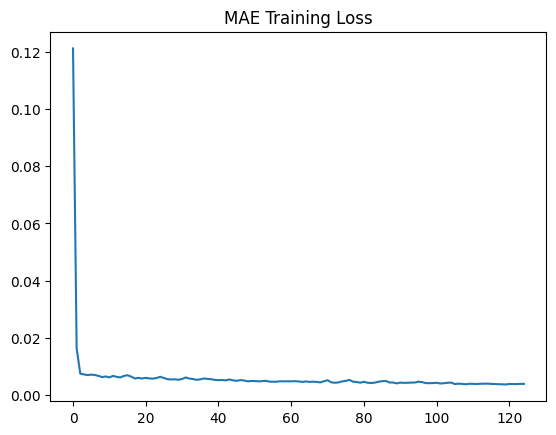

In [12]:
plt.plot(loss_history)
plt.title("MAE Training Loss")
plt.show()

# 12. Feature Extraction

In [13]:
eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def extract(model, df):
    model.eval()
    feats, labs = [], []

    with torch.no_grad():
        for _, row in df.iterrows():
            img = Image.open(row["image_path"]).convert("RGB")
            img = eval_transform(img).unsqueeze(0).to(DEVICE)

            h = model.encoder(img)

            feats.append(h.cpu().numpy().flatten())
            labs.append(row["label"])

    return np.array(feats), np.array(labs)

train_features, train_labels = extract(model, train_df)
test_features, test_labels = extract(model, test_df)

# 13. Linear Probe

In [14]:
clf = LogisticRegression(max_iter=1000)
clf.fit(train_features, train_labels)

preds = clf.predict(test_features)

print("Accuracy:", accuracy_score(test_labels, preds))
print(classification_report(test_labels, preds))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.96      0.96      0.96        74

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# 14. k-NN

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_features, train_labels)

preds = knn.predict(test_features)
print("kNN Accuracy:", accuracy_score(test_labels, preds))

kNN Accuracy: 0.9122807017543859


# 15. Label Efficiency

In [16]:
ratios = [0.01,0.05,0.1,0.25,0.5]

for r in ratios:
    X_sub, _, y_sub, _ = train_test_split(
        train_features,
        train_labels,
        train_size=r,
        stratify=train_labels,
        random_state=SEED
    )

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_sub, y_sub)

    acc = clf.score(test_features, test_labels)
    print(f"{int(r*100)}% → {acc:.4f}")

1% → 0.7807
5% → 0.8596
10% → 0.8509
25% → 0.8860
50% → 0.8947


# 16. Save Model

In [17]:
torch.save(model.state_dict(), "mae_encoder.pth")